In [16]:
%load_ext autoreload
%autoreload 2 

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## SARIMA Forecasting

This notebook develops a Seasonal Autoregressive Integrated Moving Average (SARIMA)
model to forecast daily bicycle traffic across Seattle's Fremont Bridge.

Unlike the baseline forecasting models developed previously, SARIMA is a statistical
time-series model that explicitly accounts for temporal dependence, trend, and
seasonal patterns in the data. The model combines autoregressive terms, differencing,
and moving average components to learn relationships directly from the historical
time series.

The objectives of this notebook are to

- evaluate whether the bicycle traffic series satisfies the assumptions required for SARIMA,
- transform the series into a stationary process,
- identify appropriate model parameters,
- fit and evaluate a SARIMA forecasting model,
- compare its performance with the baseline forecasting models.

In [57]:
import numpy as np
import pandas as pd
from itertools import product

import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import (plot_acf, plot_pacf)
from statsmodels.tsa.statespace.sarimax import SARIMAX
from src.models.sarima import evaluate_sarima

from src.evaluation.metrics import (
    mean_absolute_error,
    root_mean_squared_error,
    mean_absolute_percentage_error,
)

### Load Forecasting Dataset

The processed forecasting dataset created during the data preparation phase is
loaded and used throughout this notebook. Although the dataset contains weather
variables and engineered features, the initial SARIMA model is developed using
only the historical bicycle traffic observations.

Weather variables will be incorporated later using SARIMAX models.

In [18]:
features_df = pd.read_csv(
    "../data/processed/bike_weather_features.csv"
)

features_df["date"] = pd.to_datetime(features_df["date"])

features_df.info()

features_df.head()

<class 'pandas.DataFrame'>
RangeIndex: 4990 entries, 0 to 4989
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   date             4990 non-null   datetime64[us]
 1   fremont_bridge   4990 non-null   float64       
 2   temperature_2m   4990 non-null   float64       
 3   precipitation    4990 non-null   float64       
 4   wind_speed_10m   4990 non-null   float64       
 5   day_of_week      4990 non-null   int64         
 6   month            4990 non-null   int64         
 7   year             4990 non-null   int64         
 8   day_of_year      4990 non-null   int64         
 9   month_name       4990 non-null   str           
 10  is_weekend       4990 non-null   int64         
 11  lag_1            4989 non-null   float64       
 12  lag_7            4983 non-null   float64       
 13  rolling_mean_7   4984 non-null   float64       
 14  rolling_mean_30  4961 non-null   float64       
dty

,date,fremont_bridge,temperature_2m,precipitation,wind_speed_10m,day_of_week,month,year,day_of_year,month_name,is_weekend,lag_1,lag_7,rolling_mean_7,rolling_mean_30
0,2012-10-02,1938.0,13.300000,0.0,5.654545,1,10,2012,276,October,0,NaN,NaN,NaN,NaN
1,2012-10-03,3521.0,11.495833,0.0,12.845833,2,10,2012,277,October,0,1938.0,NaN,NaN,NaN
2,2012-10-04,3475.0,11.750000,0.0,11.070833,3,10,2012,278,October,0,3521.0,NaN,NaN,NaN
3,2012-10-05,3148.0,12.079167,0.0,9.095833,4,10,2012,279,October,0,3475.0,NaN,NaN,NaN
4,2012-10-06,2006.0,12.454167,0.0,8.541667,5,10,2012,280,October,1,3148.0,NaN,NaN,NaN


### Train-Test Split

The dataset is divided chronologically into training and testing sets using the
same split employed for the baseline forecasting models. Maintaining an identical
training and testing partition ensures that forecast performance can be compared
directly across all forecasting approaches.

In [19]:
split_date = "2024-06-01"

train_df = (features_df[ features_df["date"] < split_date ].copy())

test_df = (features_df[ features_df["date"] >= split_date ].copy())

### Extract Time Series

The SARIMA model is fit using only the historical Fremont Bridge bicycle traffic
counts. The training and testing time series are extracted from the corresponding
dataframes while preserving their chronological ordering.


In [20]:
#extraction
train_series = train_df.set_index("date")["fremont_bridge"]

test_series = test_df.set_index("date")["fremont_bridge"]

#validation
print(train_series.head())

print()

print(train_series.index)

date
2012-10-02    1938.0
2012-10-03    3521.0
2012-10-04    3475.0
2012-10-05    3148.0
2012-10-06    2006.0
Name: fremont_bridge, dtype: float64

DatetimeIndex(['2012-10-02', '2012-10-03', '2012-10-04', '2012-10-05',
               '2012-10-06', '2012-10-07', '2012-10-08', '2012-10-09',
               '2012-10-10', '2012-10-11',
               ...
               '2024-05-22', '2024-05-23', '2024-05-24', '2024-05-25',
               '2024-05-26', '2024-05-27', '2024-05-28', '2024-05-29',
               '2024-05-30', '2024-05-31'],
              dtype='datetime64[us]', name='date', length=4260, freq=None)


### Stationarity Analysis

Before fitting a SARIMA model, the time series should be
approximately stationary. A stationary time series has
statistical properties, such as its mean and variance,
that remain approximately constant over time.

Visual inspection provides an initial assessment of
whether the Fremont Bridge bicycle traffic data exhibit
long-term trends, changing variability, or seasonal
patterns that may violate the stationarity assumption.

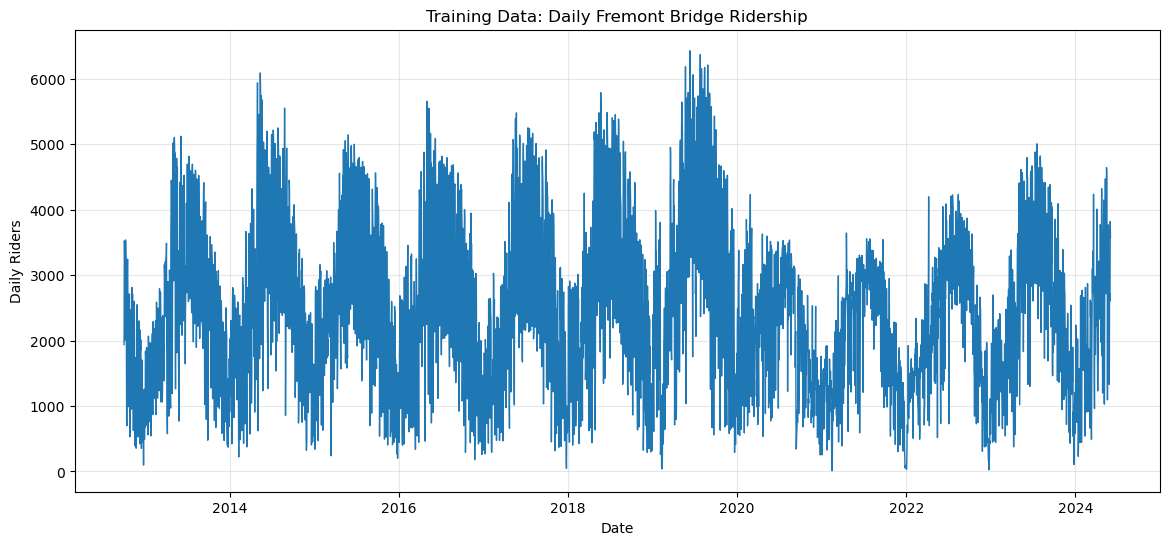

In [21]:
plt.figure(figsize=(14,6))

plt.plot(train_series.index, train_series, linewidth=1)

plt.title("Training Data: Daily Fremont Bridge Ridership")
plt.xlabel("Date")
plt.ylabel("Daily Riders")
plt.grid(alpha=0.3)

plt.show()

#### Interpretation

The training time series exhibits several characteristics
that suggest it is not stationary.

The average bicycle traffic changes substantially over
time, including long-term growth, a pronounced decline
during the COVID-19 pandemic, and subsequent recovery.
These changes indicate that the mean of the series is not
constant.

The series also displays strong annual seasonality, with
higher ridership during the summer months and lower
ridership during the winter months. This repeating
seasonal structure further violates the assumption of
stationarity required by classical ARIMA models.

These observations suggest that the time series will
require both ordinary and seasonal differencing before a
SARIMA model can be fit.

### Augmented Dickey-Fuller Test

Visual inspection suggests that the Fremont Bridge bicycle
traffic series is not stationary. The Augmented
Dickey-Fuller (ADF) test provides a formal statistical
test for stationarity by evaluating whether the time
series contains a unit root.

The hypotheses are

- Null hypothesis ($H_0$): The series contains a unit root and is nonstationary.
- Alternative hypothesis ($H_1$): The series does not contain a unit root and is stationary.

A small p-value (typically less than 0.05) indicates
sufficient evidence to reject the null hypothesis and
conclude that the series is stationary.

In [22]:
#run test
adf_result = adfuller(train_series)

#result examination
print(f"ADF Statistic : {adf_result[0]:.4f}")
print(f"p-value       : {adf_result[1]:.4f}")
print(f"Lags Used     : {adf_result[2]}")
print(f"Observations  : {adf_result[3]}")

print("\nCritical Values")

for key, value in adf_result[4].items():
    print(f"{key}: {value:.4f}")

ADF Statistic : -4.1217
p-value       : 0.0009
Lags Used     : 30
Observations  : 4229

Critical Values
1%: -3.4319
5%: -2.8622
10%: -2.5671


#### Interpretation

The Augmented Dickey–Fuller test rejects the null hypothesis of a unit root (p < 0.001), providing statistical evidence that the training series is stationary in the sense tested by the ADF procedure. However, visual inspection of the series reveals clear annual and weekly seasonal patterns, indicating that the series still contains deterministic temporal structure. Consequently, additional analyses of autocorrelation and seasonality remain necessary before selecting an appropriate SARIMA model.

### Autocorrelation Analysis

Although the Augmented Dickey-Fuller test rejected the
presence of a unit root, the training series exhibits
clear temporal structure that may influence model
selection.

The Autocorrelation Function (ACF) and Partial
Autocorrelation Function (PACF) summarize the
relationships between observations separated by different
time lags. These diagnostics provide insight into the
dependence structure of the series and help guide the
selection of autoregressive and moving average terms in
the SARIMA model.

<Figure size 1200x500 with 0 Axes>

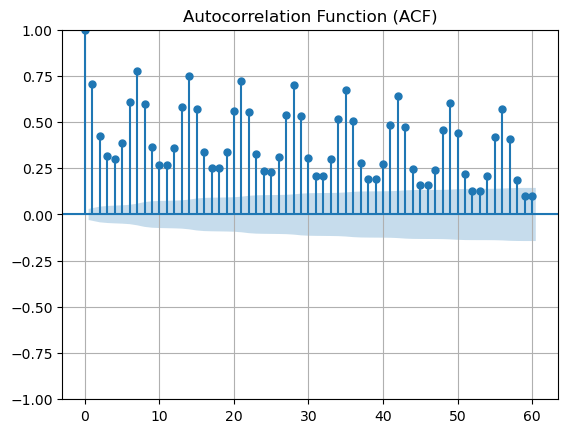

<Figure size 1200x500 with 0 Axes>

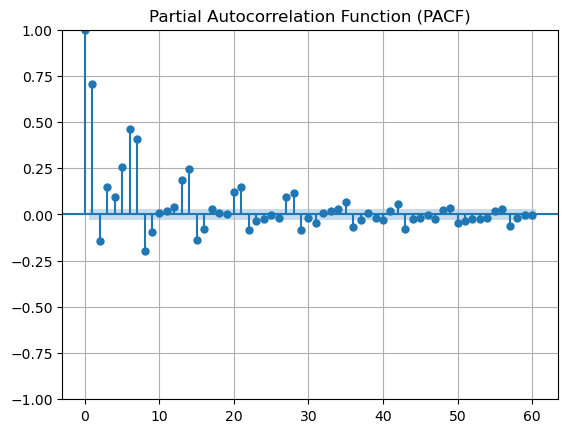

In [23]:
plt.figure(figsize=(12,5))

#plot acf
plot_acf(train_series, lags=60)

plt.title("Autocorrelation Function (ACF)")
plt.grid()
plt.show()

#plot pacf
plt.figure(figsize=(12,5))

plot_pacf(train_series, lags=60, method="ywm")

plt.title("Partial Autocorrelation Function (PACF)")
plt.grid()
plt.show()

### Initial Model Selection

The ADF test, ACF, and PACF diagnostics suggest that the
Fremont Bridge bicycle traffic series exhibits strong
short-term autocorrelation and pronounced weekly
seasonality.

Based on these diagnostics, an initial
SARIMA(1,0,1)(1,0,1)₇ model is selected. This
specification provides a parsimonious starting point that
captures both non-seasonal and weekly temporal
dependence while avoiding unnecessary model complexity.

The adequacy of this initial specification will be
evaluated using residual diagnostics and forecast
performance. If necessary, alternative model
specifications will be explored in subsequent analyses.

In [26]:
#build model
sarima_model = SARIMAX(train_series, order=(1, 0, 1), seasonal_order=(1, 0, 1, 7), 
                       enforce_stationarity=False,
                       enforce_invertibility=False)

#fit the model
sarima_results = sarima_model.fit()
print(sarima_results.summary())

C:\Users\johnw\anaconda3\envs\bike_forecasting\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\johnw\anaconda3\envs\bike_forecasting\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                     
Dep. Variable:                    fremont_bridge   No. Observations:                 4260
Model:             SARIMAX(1, 0, 1)x(1, 0, 1, 7)   Log Likelihood              -33300.135
Date:                           Wed, 01 Jul 2026   AIC                          66610.269
Time:                                   11:04:38   BIC                          66642.044
Sample:                               10-02-2012   HQIC                         66621.498
                                    - 05-31-2024                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.7914      0.014     55.709      0.000       0.764       0.819
ma.L1         -0.3020      0.020    -15.112

#### Interpretation

The fitted SARIMA model indicates that both recent observations and weekly seasonal patterns contribute significantly to forecasting daily bicycle traffic. The estimated seasonal autoregressive coefficient ($\Phi_1
=0.993$) is particularly large, demonstrating that bicycle traffic on a given weekday is highly predictive of traffic on the corresponding weekday one week later. All estimated parameters are statistically significant (p < 0.001), and the Ljung–Box test suggests that the residuals exhibit little remaining autocorrelation, indicating that the model has captured much of the temporal dependence present in the training data.

### Residual Diagnostics

Residual analysis provides an important assessment of
whether the fitted SARIMA model has adequately captured
the temporal structure of the bicycle traffic series.

Ideally, the residuals should resemble white noise,
exhibiting no systematic trends, seasonality, or
autocorrelation. Any remaining structure suggests that
the model has failed to explain some component of the
underlying process.

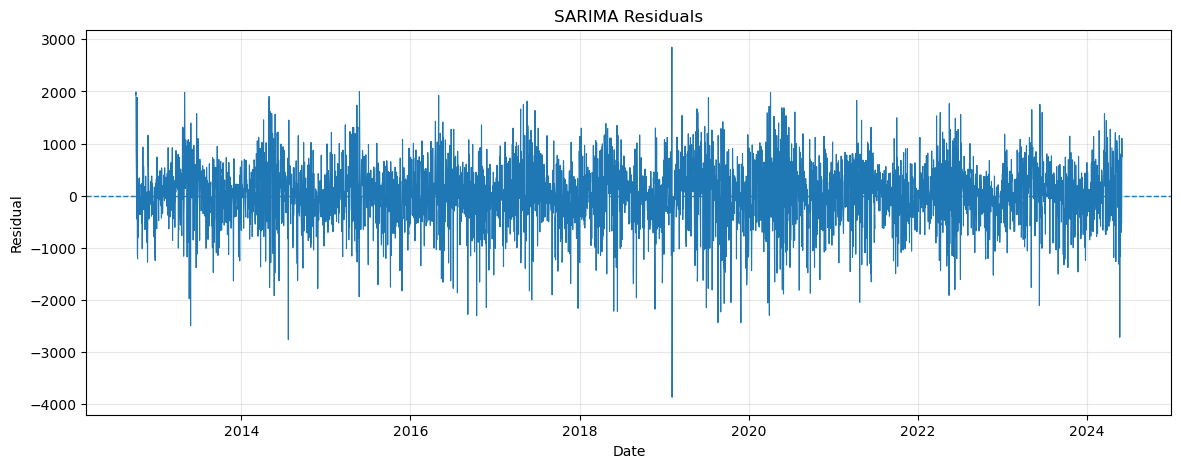

In [28]:
residuals = sarima_results.resid

residuals.head()

plt.figure(figsize=(14,5))

plt.plot(residuals.index, residuals, linewidth=0.8)

plt.axhline(0, linestyle="--", linewidth=1)

plt.title("SARIMA Residuals")
plt.xlabel("Date")
plt.ylabel("Residual")
plt.grid(alpha=0.3)
plt.show()

### Residual Autocorrelation

A well-specified SARIMA model should remove the temporal
dependence present in the original time series. The
Autocorrelation Function (ACF) of the residuals is used
to determine whether any systematic correlation remains.

Ideally, all autocorrelations should lie within the
95% confidence intervals, indicating that the residuals
behave like white noise.

<Figure size 1200x500 with 0 Axes>

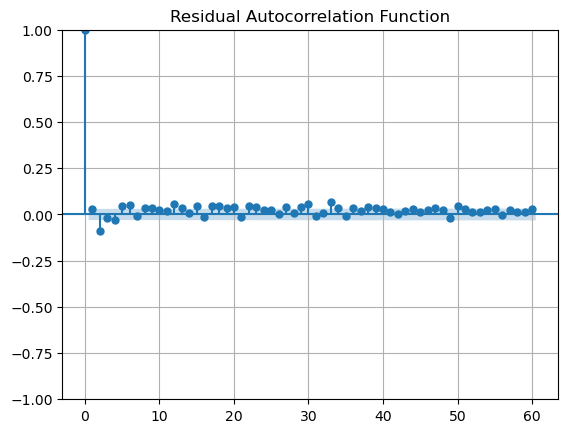

In [29]:
plt.figure(figsize=(12,5))

plot_acf(residuals, lags=60)

plt.title("Residual Autocorrelation Function")
plt.grid()
plt.show()

#### Interpretation

The residual autocorrelation function shows that the fitted SARIMA model has removed nearly all of the temporal dependence present in the original bicycle traffic series. Nearly all residual autocorrelations lie within the 95% confidence intervals and fluctuate randomly around zero, indicating that the residuals closely resemble white noise. In particular, the pronounced weekly autocorrelation observed in the original data is no longer present, demonstrating that the seasonal components of the SARIMA model have successfully captured the recurring weekly commuter cycle. Together with the Ljung–Box test, these results provide strong evidence that the fitted model adequately represents the underlying temporal structure of the training data.

### Forecast the Test Period

The fitted SARIMA model is used to forecast bicycle
traffic over the testing period. Forecasts are generated
without using any information from the testing data,
providing an unbiased assessment of predictive
performance on unseen observations.

In [31]:
#get model
forecast = sarima_results.get_forecast(steps=len(test_series))

#extract predicted values
sarima_pred = forecast.predicted_mean

print(sarima_pred.head())

#validation
sarima_pred = forecast.predicted_mean
sarima_pred.head()

2024-06-01    2305.957653
2024-06-02    2204.870118
2024-06-03    2952.573471
2024-06-04    3249.427671
2024-06-05    3415.355621
Freq: D, Name: predicted_mean, dtype: float64


2024-06-01    2305.957653
2024-06-02    2204.870118
2024-06-03    2952.573471
2024-06-04    3249.427671
2024-06-05    3415.355621
Freq: D, Name: predicted_mean, dtype: float64

In [32]:
#confidence intervals
confidence = forecast.conf_int()

confidence.head()

,lower fremont_bridge,upper fremont_bridge
2024-06-01,1109.791261,3502.124044
2024-06-02,873.115833,3536.624402
2024-06-03,1542.521189,4362.625753
2024-06-04,1792.476519,4706.378822
2024-06-05,1929.784189,4900.927053


### Forecast Visualization

The SARIMA forecasts are compared with the observed
bicycle traffic over the testing period. The shaded
region represents the 95% confidence interval associated
with each forecast, illustrating the uncertainty of the
model as predictions extend further into the future.

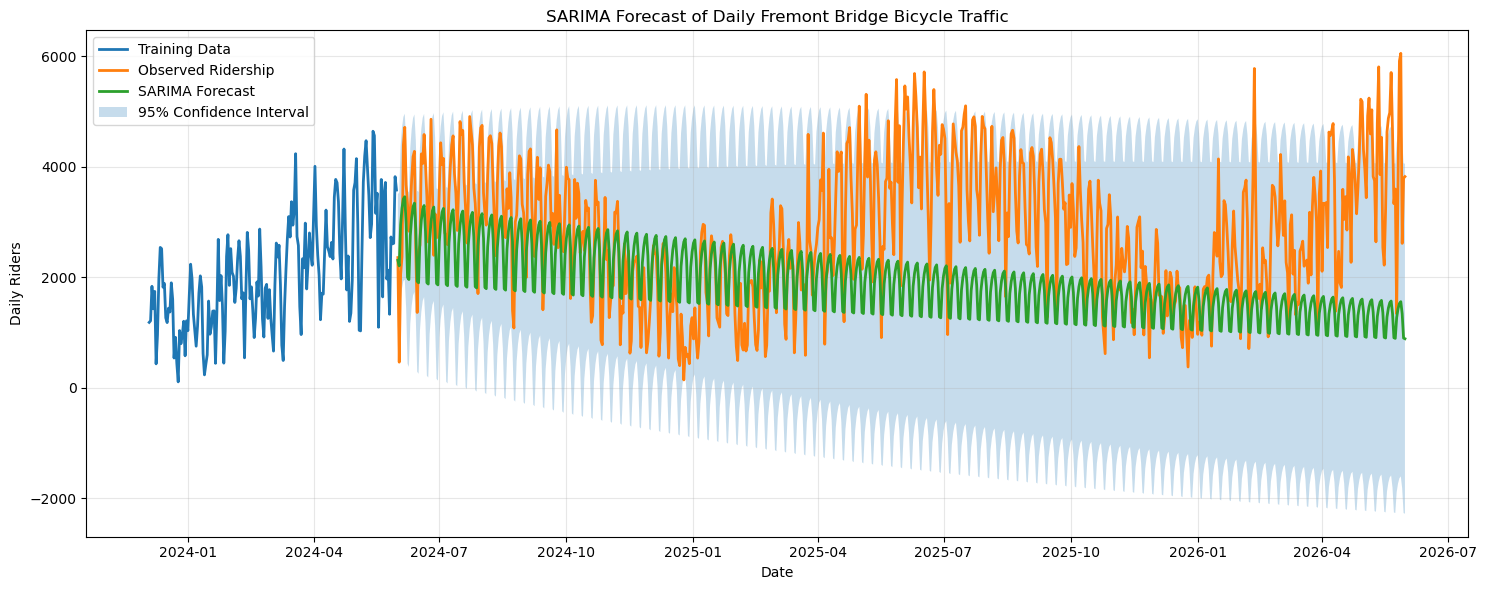

In [33]:
plt.figure(figsize=(15,6))

# Last 180 days of training data
plt.plot(train_series.iloc[-180:], label="Training Data", linewidth=2)

# Actual test data
plt.plot(test_series, label="Observed Ridership", linewidth=2)

# Forecast
plt.plot(sarima_pred, label="SARIMA Forecast", linewidth=2)

# Confidence interval
plt.fill_between(
    confidence.index,
    confidence.iloc[:, 0],
    confidence.iloc[:, 1],
    alpha=0.25,
    label="95% Confidence Interval"
)

plt.title("SARIMA Forecast of Daily Fremont Bridge Bicycle Traffic")
plt.xlabel("Date")
plt.ylabel("Daily Riders")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("../reports/figures/sarima_forecast.png", dpi=300, bbox_inches="tight" )
plt.show()

### Hyperparameter Search

The initial SARIMA model provides a useful starting point, but there is no guarantee that it is the optimal forecasting model. Rather than manually testing additional parameter combinations, we perform a systematic grid search over a small range of non-seasonal and seasonal parameters.

Each candidate model is evaluated using:

- AIC
- MAE
- RMSE
- MAPE

The final model is selected using out-of-sample forecasting performance.

In [42]:
#perform grid search

# Non-seasonal parameters
p = [0, 1, 2]
d = [0, 1]
q = [0, 1, 2]

# Seasonal parameters
P = [0, 1]
D = [0, 1]
Q = [0, 1]

m = 7

orders = list(product(p, d, q))
seasonal_orders = list(product(P, D, Q))

#storage
results = []

total_models = len(orders) * len(seasonal_orders)

model_number = 1

for order in orders:

    for seasonal in seasonal_orders:

        seasonal_order = (
            seasonal[0],
            seasonal[1],
            seasonal[2],
            m
        )

        print(
            f"[{model_number}/{total_models}] "
            f"{order} x {seasonal_order}"
        )

        result = evaluate_sarima(
            train_series=train_series,
            test_series=test_series,
            order=order,
            seasonal_order=seasonal_order
        )

        results.append(result)

        model_number += 1

results_df = pd.DataFrame(results)

[1/144] (0, 0, 0) x (0, 0, 0, 7)


C:\Users\johnw\anaconda3\envs\bike_forecasting\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\johnw\anaconda3\envs\bike_forecasting\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


[2/144] (0, 0, 0) x (0, 0, 1, 7)


C:\Users\johnw\anaconda3\envs\bike_forecasting\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\johnw\anaconda3\envs\bike_forecasting\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


[3/144] (0, 0, 0) x (0, 1, 0, 7)


...

[143/144] (2, 1, 2) x (1, 1, 0, 7)


C:\Users\johnw\anaconda3\envs\bike_forecasting\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\johnw\anaconda3\envs\bike_forecasting\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


[144/144] (2, 1, 2) x (1, 1, 1, 7)


C:\Users\johnw\anaconda3\envs\bike_forecasting\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\johnw\anaconda3\envs\bike_forecasting\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\johnw\anaconda3\envs\bike_forecasting\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


,order,seasonal_order,AIC,BIC,MAE,RMSE,MAPE,success
0,"(1, 1, 2)","(1, 1, 1, 7)",66323.080730,66361.197471,2901.514207,3373.956240,1.622695,True
1,"(1, 1, 2)","(0, 1, 1, 7)",66325.513142,66357.277092,2933.595882,3410.183444,1.637009,True
2,"(1, 1, 1)","(1, 1, 1, 7)",66336.716642,66368.481771,2898.958725,3371.128243,1.621437,True
3,"(2, 1, 1)","(1, 1, 1, 7)",66338.712123,66376.830278,2894.081767,3365.682173,1.619116,True
4,"(1, 1, 1)","(0, 1, 1, 7)",66338.958352,66364.370456,2932.496531,3408.961957,1.636472,True
5,"(2, 1, 1)","(0, 1, 1, 7)",66340.948455,66372.713584,2924.840595,3400.420229,1.632833,True
6,"(1, 0, 2)","(0, 1, 1, 7)",66360.698734,66392.463863,929.774999,1099.003525,0.505934,True
7,"(1, 0, 2)","(1, 1, 1, 7)",66362.607432,66400.725587,929.780674,1099.026524,0.505424,True
8,"(0, 1, 2)","(0, 1, 1, 7)",66386.682280,66412.093440,2219.153464,2620.119995,1.294745,True
9,"(0, 1, 2)","(1, 1, 1, 7)",66387.809384,66419.573335,2218.928616,2619.889154,1.295027,True


In [52]:
results_df = (
    results_df
    .query("success == True")
    .sort_values("RMSE")
    .reset_index(drop=True)
)

results_df[
    [
        "order",
        "seasonal_order",
        "AIC",
        "MAE",
        "RMSE",
        "MAPE"
    ]
].head(10)

,order,seasonal_order,AIC,MAE,RMSE,MAPE
0,"(2, 0, 2)","(1, 1, 1, 7)",66737.911611,929.133991,1098.404964,0.542725
1,"(1, 0, 2)","(0, 1, 1, 7)",66360.698734,929.774999,1099.003525,0.505934
2,"(1, 0, 2)","(1, 1, 1, 7)",66362.607432,929.780674,1099.026524,0.505424
3,"(1, 0, 1)","(1, 1, 1, 7)",66516.466541,932.237628,1104.516804,0.519068
4,"(1, 0, 1)","(0, 1, 1, 7)",66514.466591,932.239731,1104.521409,0.519082
5,"(2, 0, 0)","(0, 1, 1, 7)",66563.480127,933.679298,1106.827421,0.523073
6,"(2, 0, 0)","(1, 1, 1, 7)",66549.341169,933.780353,1107.009026,0.523440
7,"(1, 0, 0)","(0, 1, 1, 7)",66610.287002,935.286661,1109.619236,0.524488
8,"(2, 0, 2)","(0, 1, 1, 7)",66746.684160,936.601621,1109.955558,0.559549
9,"(1, 0, 0)","(1, 1, 1, 7)",66612.058471,935.611527,1110.118171,0.525217


The candidate models are ranked according to out-of-sample RMSE. Although AIC is useful for comparing statistical models, the objective of this project is accurate forecasting on unseen data. Therefore, the model with the lowest RMSE is selected for the final analysis.

In [53]:
#extract best parameters
best_result = results_df.iloc[0]

best_order = best_result["order"]
best_seasonal_order = best_result["seasonal_order"]

print("Best SARIMA Model")
print("-----------------")
print(f"Order:           {best_order}")
print(f"Seasonal Order:  {best_seasonal_order}")
print(f"RMSE:            {best_result['RMSE']:.2f}")

Best SARIMA Model
-----------------
Order:           (2, 0, 2)
Seasonal Order:  (1, 1, 1, 7)
RMSE:            1098.40


In [54]:
#refit model
best_model = SARIMAX(
    train_series,
    order=best_order,
    seasonal_order=best_seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
)

best_fit = best_model.fit(disp=False)

C:\Users\johnw\anaconda3\envs\bike_forecasting\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\johnw\anaconda3\envs\bike_forecasting\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\johnw\anaconda3\envs\bike_forecasting\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


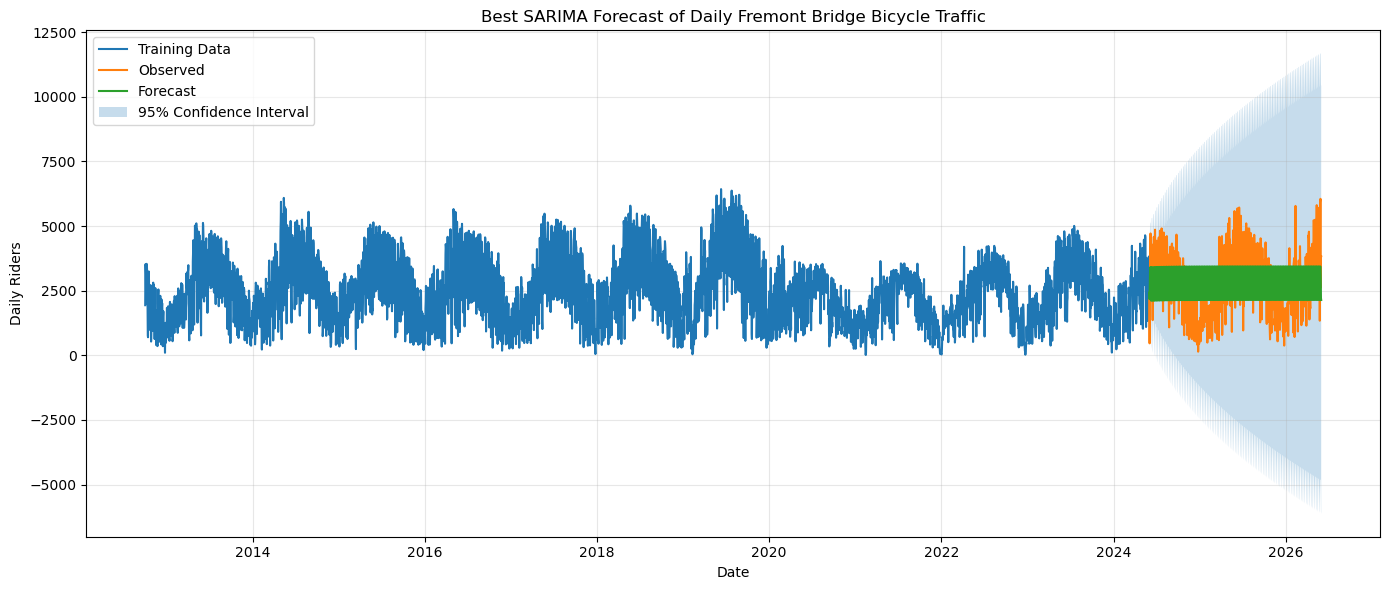

                                      SARIMAX Results                                      
Dep. Variable:                      fremont_bridge   No. Observations:                 4260
Model:             SARIMAX(2, 0, 2)x(1, 1, [1], 7)   Log Likelihood              -33361.956
Date:                             Wed, 01 Jul 2026   AIC                          66737.912
Time:                                     12:30:54   BIC                          66782.383
Sample:                                 10-02-2012   HQIC                         66753.628
                                      - 05-31-2024                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.4036      0.075     18.708      0.000       1.257       1.551
ar.L2         -0.4113      

In [55]:
#forecast
forecast = best_fit.get_forecast(steps=len(test_series))

forecast_mean = forecast.predicted_mean
confidence = forecast.conf_int()

#plot
plt.figure(figsize=(14, 6))

# Training data
plt.plot(
    train_series.index,
    train_series,
    label="Training Data"
)

# Actual observations
plt.plot(
    test_series.index,
    test_series,
    label="Observed"
)

# Forecast
plt.plot(
    forecast_mean.index,
    forecast_mean,
    label="Forecast"
)

# Confidence interval
plt.fill_between(
    confidence.index,
    confidence.iloc[:, 0],
    confidence.iloc[:, 1],
    alpha=0.25,
    label="95% Confidence Interval"
)

plt.title("Best SARIMA Forecast of Daily Fremont Bridge Bicycle Traffic")
plt.xlabel("Date")
plt.ylabel("Daily Riders")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig("../reports/figures/best_sarima_forecast.png", dpi=300, bbox_inches="tight")

plt.show()

print(best_fit.summary())

In [59]:
forecast = best_fit.get_forecast(steps=len(test_series))

predictions = forecast.predicted_mean

mae = mean_absolute_error(
    test_series,
    predictions
)

rmse = root_mean_squared_error(
    test_series,
    predictions
)

mape = mean_absolute_percentage_error(
    test_series,
    predictions
)

print(f"MAE : {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2f}%")

MAE : 929.13
RMSE: 1098.40
MAPE: 54.27%


In [60]:
# Display the five best-performing SARIMA models with ranking
top5_models = (
    results_df[
        [
            "order",
            "seasonal_order",
            "AIC",
            "MAE",
            "RMSE",
            "MAPE",
        ]
    ]
    .head(5)
    .reset_index(drop=True)
)

top5_models.index = top5_models.index + 1
top5_models.index.name = "Rank"

top5_models

,order,seasonal_order,AIC,MAE,RMSE,MAPE
Rank,,,,,,
1,"(2, 0, 2)","(1, 1, 1, 7)",66737.911611,929.133991,1098.404964,0.542725
2,"(1, 0, 2)","(0, 1, 1, 7)",66360.698734,929.774999,1099.003525,0.505934
3,"(1, 0, 2)","(1, 1, 1, 7)",66362.607432,929.780674,1099.026524,0.505424
4,"(1, 0, 1)","(1, 1, 1, 7)",66516.466541,932.237628,1104.516804,0.519068
5,"(1, 0, 1)","(0, 1, 1, 7)",66514.466591,932.239731,1104.521409,0.519082


Rank 1
Order: (2, 0, 2)
Seasonal Order: (1, 1, 1, 7)
AIC : 66737.91
MAE : 929.13
RMSE: 1098.40
MAPE: 54.27%


C:\Users\johnw\anaconda3\envs\bike_forecasting\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\johnw\anaconda3\envs\bike_forecasting\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\johnw\anaconda3\envs\bike_forecasting\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


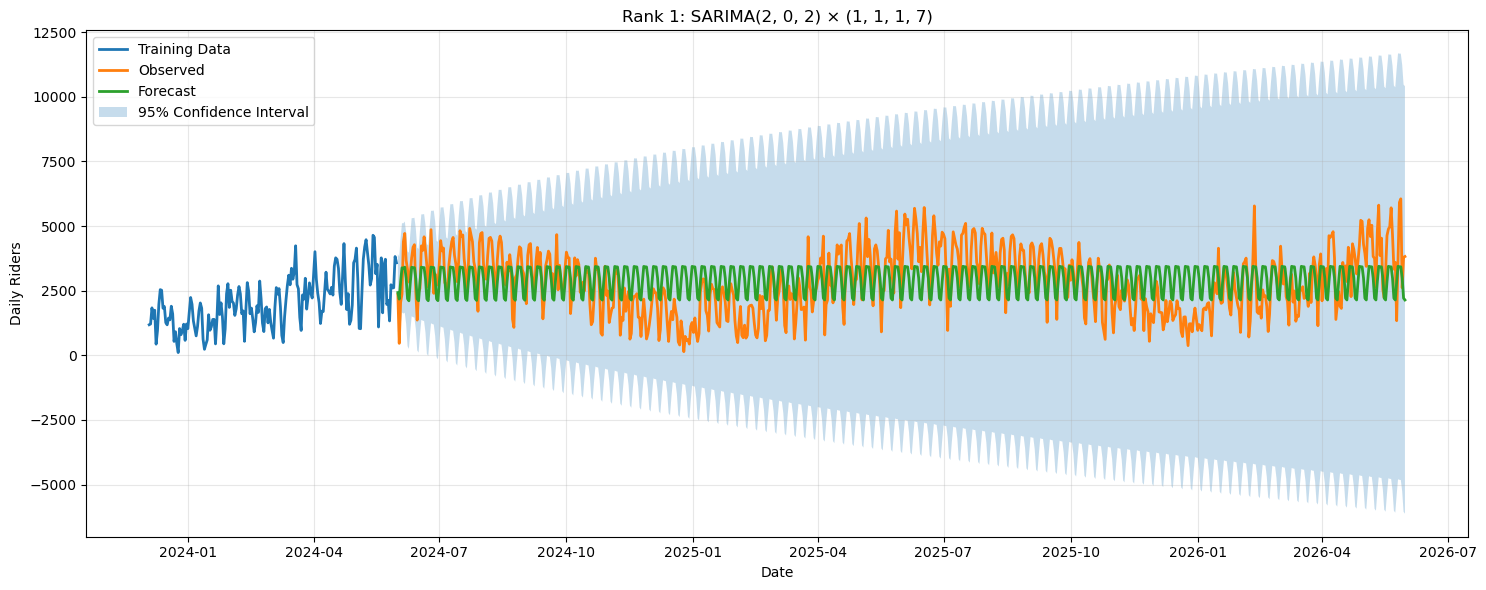

Rank 2
Order: (1, 0, 2)
Seasonal Order: (0, 1, 1, 7)
AIC : 66360.70
MAE : 929.77
RMSE: 1099.00
MAPE: 50.59%


C:\Users\johnw\anaconda3\envs\bike_forecasting\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\johnw\anaconda3\envs\bike_forecasting\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


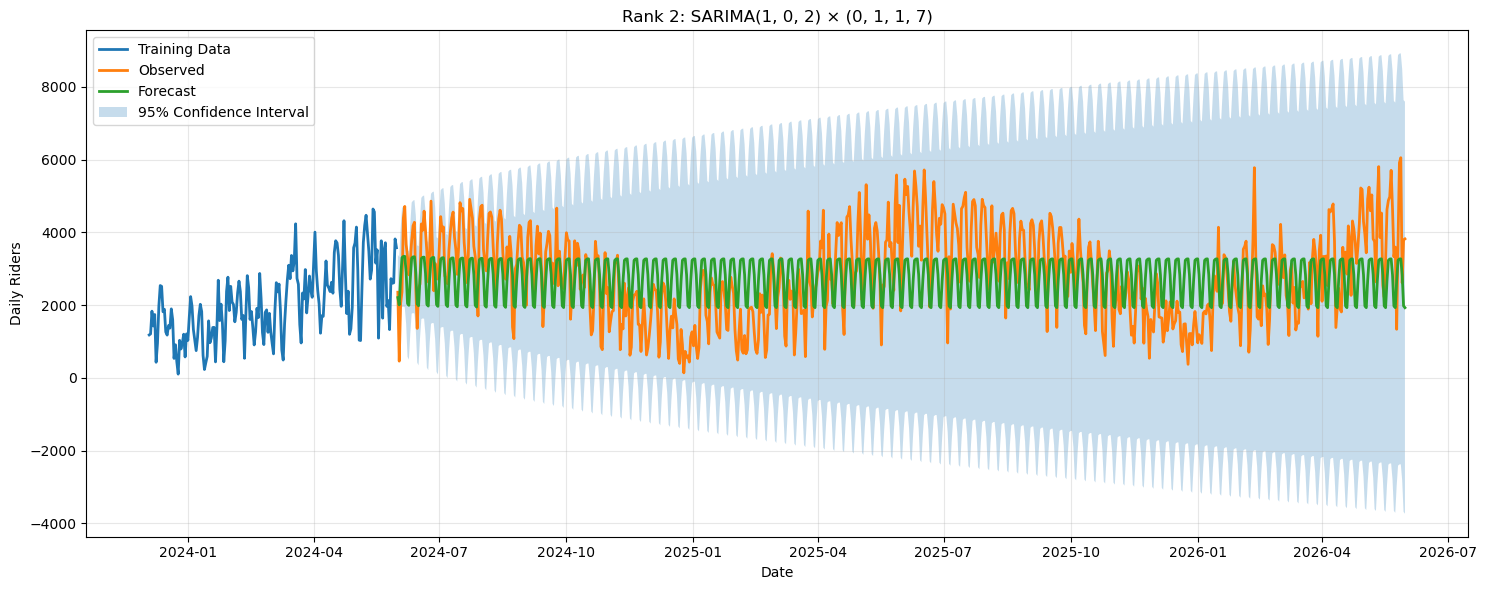

Rank 3
Order: (1, 0, 2)
Seasonal Order: (1, 1, 1, 7)
AIC : 66362.61
MAE : 929.78
RMSE: 1099.03
MAPE: 50.54%


C:\Users\johnw\anaconda3\envs\bike_forecasting\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\johnw\anaconda3\envs\bike_forecasting\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


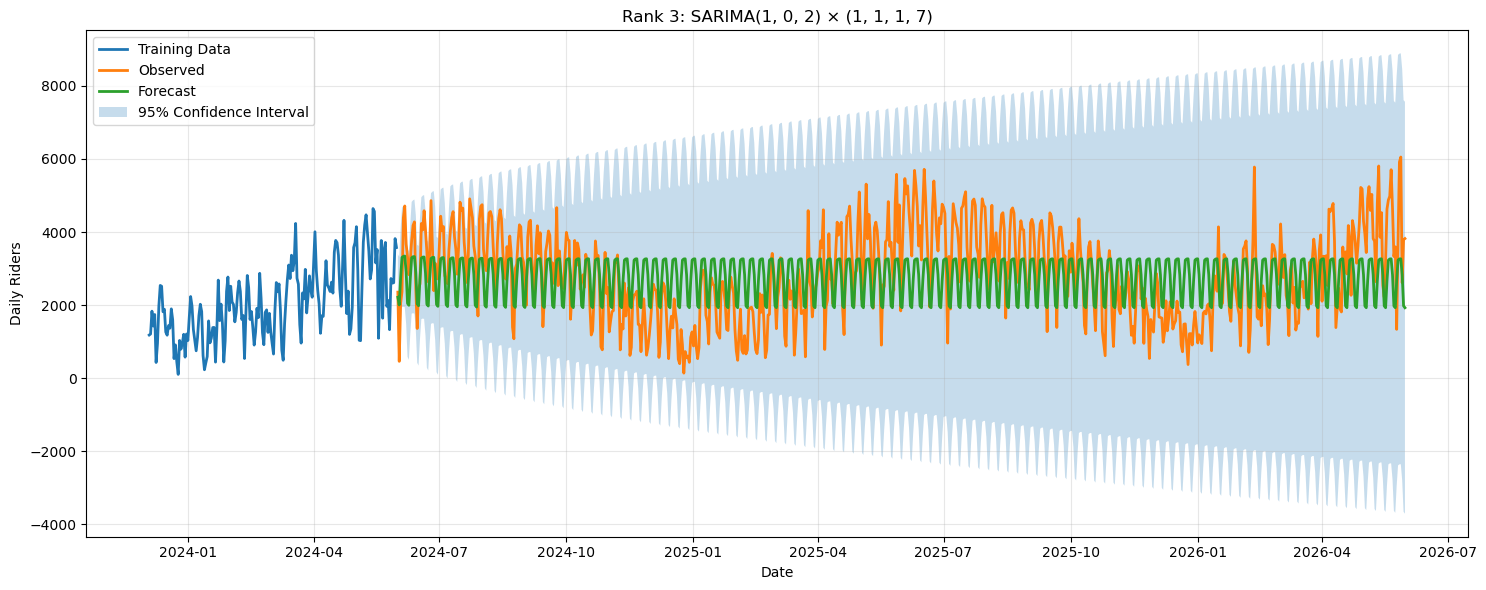

Rank 4
Order: (1, 0, 1)
Seasonal Order: (1, 1, 1, 7)
AIC : 66516.47
MAE : 932.24
RMSE: 1104.52
MAPE: 51.91%


C:\Users\johnw\anaconda3\envs\bike_forecasting\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\johnw\anaconda3\envs\bike_forecasting\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


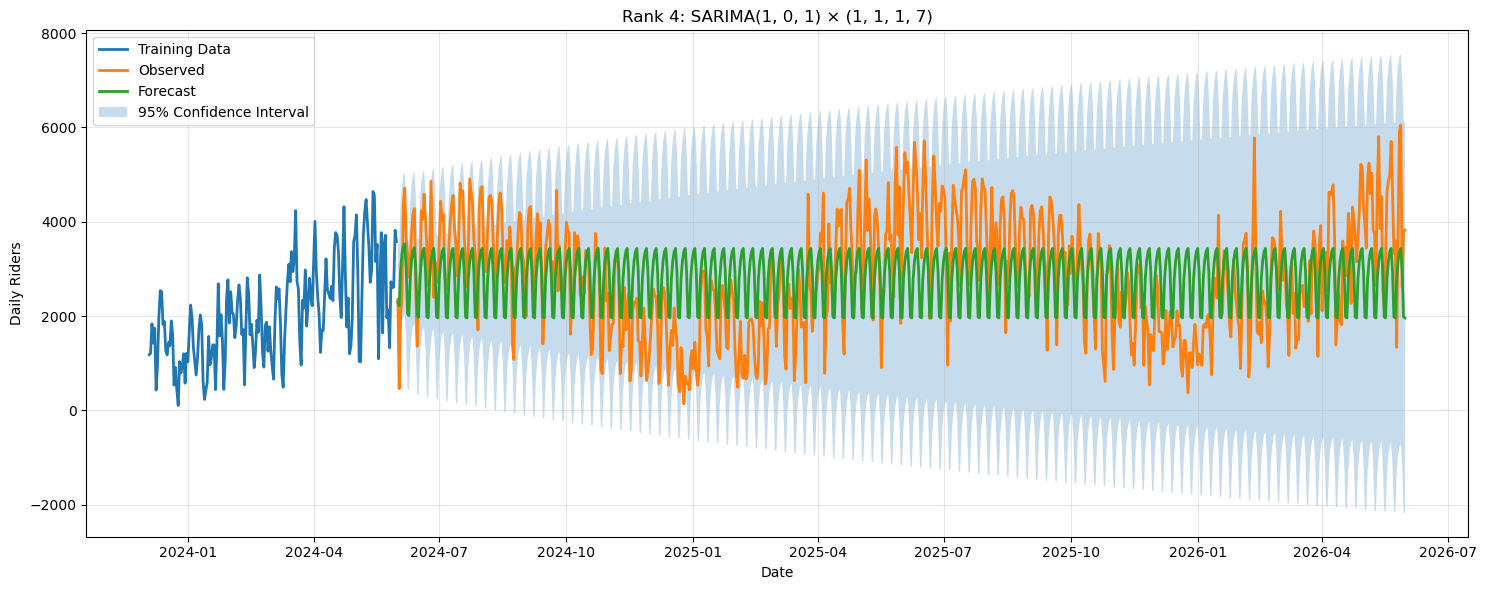

Rank 5
Order: (1, 0, 1)
Seasonal Order: (0, 1, 1, 7)
AIC : 66514.47
MAE : 932.24
RMSE: 1104.52
MAPE: 51.91%


C:\Users\johnw\anaconda3\envs\bike_forecasting\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\johnw\anaconda3\envs\bike_forecasting\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


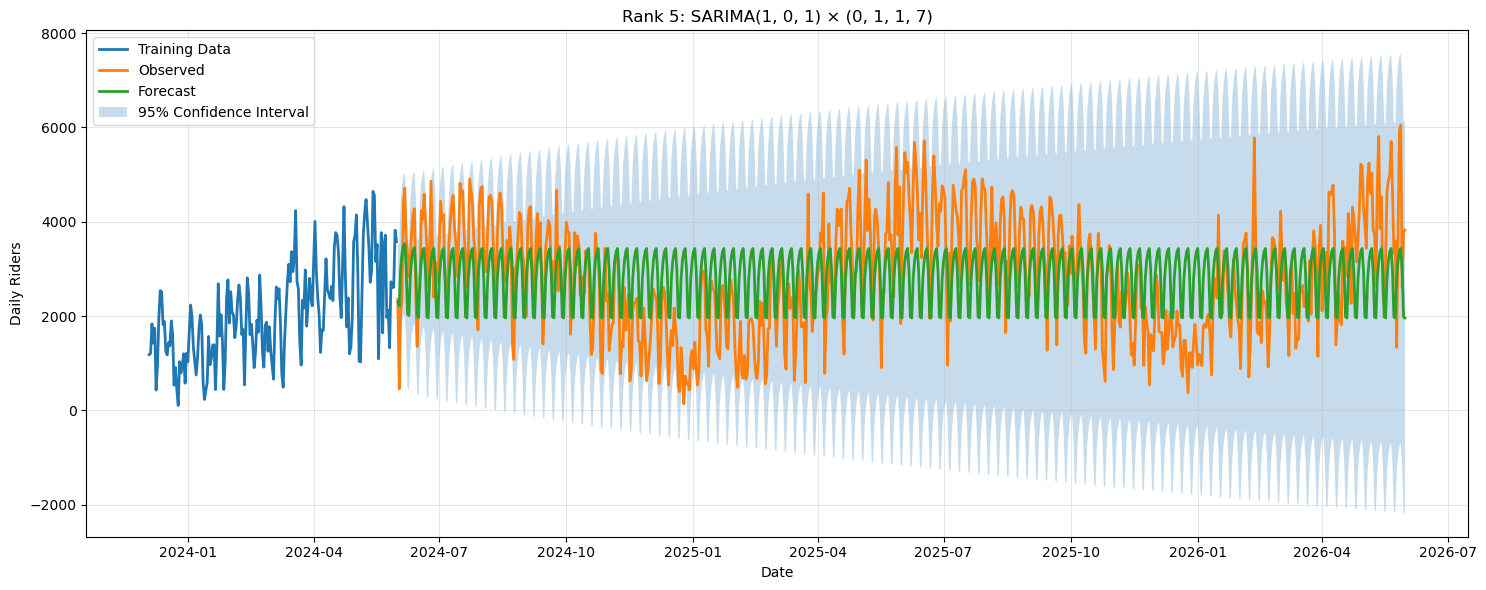

In [61]:
#Compare the top five SARIMA models

top5 = results_df.head(5)

for rank, (_, row) in enumerate(top5.iterrows(), start=1):

    order = row["order"]
    seasonal_order = row["seasonal_order"]

    print("=" * 80)
    print(f"Rank {rank}")
    print(f"Order: {order}")
    print(f"Seasonal Order: {seasonal_order}")
    print(f"AIC : {row['AIC']:.2f}")
    print(f"MAE : {row['MAE']:.2f}")
    print(f"RMSE: {row['RMSE']:.2f}")
    print(f"MAPE: {row['MAPE']:.2%}")

    # Fit model
    model = SARIMAX(
        train_series,
        order=order,
        seasonal_order=seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    results = model.fit(disp=False)

    # Forecast
    forecast = results.get_forecast(
        steps=len(test_series)
    )

    predictions = forecast.predicted_mean
    confidence = forecast.conf_int()

    # Plot
    plt.figure(figsize=(15,6))

    plt.plot(
        train_series.iloc[-180:],
        label="Training Data",
        linewidth=2
    )

    plt.plot(
        test_series,
        label="Observed",
        linewidth=2
    )

    plt.plot(
        predictions,
        label="Forecast",
        linewidth=2
    )

    plt.fill_between(
        confidence.index,
        confidence.iloc[:,0],
        confidence.iloc[:,1],
        alpha=0.25,
        label="95% Confidence Interval"
    )

    plt.title(
        f"Rank {rank}: SARIMA{order} × {seasonal_order}"
    )

    plt.xlabel("Date")
    plt.ylabel("Daily Riders")

    plt.grid(alpha=0.3)
    plt.legend()

    plt.tight_layout()

    plt.show()

#### Interpretation

A systematic grid search identified the best-performing SARIMA specification within the tested parameter space. However, despite careful model selection, the SARIMA forecasts did not consistently outperform the simpler seasonal baseline models. This suggests that much of the predictable structure in daily bicycle traffic is already captured by the weekly seasonal cycle and that additional improvements likely require exogenous variables such as weather and calendar effects. The next notebook therefore extends the analysis to SARIMAX models that incorporate these external predictors.

### Conclusions

This notebook investigated Seasonal ARIMA models for forecasting daily bicycle traffic across the Fremont Bridge.

An initial SARIMA model was constructed using insights from the ACF and PACF diagnostics and evaluated through residual analysis. A systematic grid search over multiple combinations of non-seasonal and seasonal parameters was then performed to identify the strongest-performing model based on out-of-sample forecasting metrics.

Although several SARIMA models produced reasonable forecasts, none consistently outperformed the simpler Seasonal Naïve baseline developed in the previous notebook. This suggests that much of the predictable structure in the ridership data is already explained by the weekly commuting cycle. Remaining forecast errors are likely driven by external factors such as weather conditions, holidays, and long-term trends that are not represented in a univariate SARIMA model.

The next stage of the project will therefore extend the analysis to SARIMAX, incorporating weather and calendar variables to determine whether exogenous information improves forecasting performance.